In [1]:
import geopandas as gpd
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
radar_id = '26'
year = '2026'
month = '02'
# day = '12'
hydrophone = 'orcasound_lab'

# Read Sound data

In [3]:
psd_df = pd.read_parquet(f'data/sound/psd/hydrophone={hydrophone}/year={year}/month={month}').sort_index().reset_index()
bb_df = pd.read_parquet(f'data/sound/broadband/hydrophone={hydrophone}/year={year}/month={month}').sort_index().reset_index()

In [4]:
print(psd_df.shape)
print(bb_df.shape)
psd_df.head()

(1049800, 104)
(1049800, 3)


,index,67,71,75,80,85,90,95,100,106,...,14000,15000,16000,17000,18000,19000,20000,21200,22400,day
0,2026-02-07 12:18:13,17.000665,19.294618,20.197513,19.322835,18.659616,21.115209,20.999857,22.689917,19.256854,...,25.338738,24.875638,24.568007,13.515567,7.604225,6.887845,7.158697,5.933304,4.608978,7
1,2026-02-07 12:18:14,19.467176,19.457936,21.374846,21.176110,22.079493,22.903928,21.202620,23.469553,20.831801,...,26.141359,25.771691,25.326986,16.547385,0.382326,-0.724243,-2.974833,-8.635966,-16.193366,7
2,2026-02-07 12:18:15,19.811217,19.420876,21.221506,21.924292,21.787503,23.446219,22.431197,22.463962,21.759176,...,26.209618,25.847337,25.473912,20.664453,15.685212,-1.723723,-3.944525,-6.285165,-21.411621,7
3,2026-02-07 12:18:16,18.480414,18.302718,20.319762,23.340436,22.431197,22.981302,22.731241,22.208427,20.720595,...,26.226599,25.966143,25.476224,16.914360,0.546992,-0.963539,-3.478504,-8.068058,-14.199308,7
4,2026-02-07 12:18:17,18.840161,18.418112,19.089674,21.330246,21.882432,22.463962,22.962795,22.295555,21.965951,...,26.359178,26.087656,25.647910,17.122489,0.546992,-1.012200,-4.436975,-9.499104,-16.478175,7


In [5]:
bb_df.head()

,index,0,day
0,2026-02-07 12:18:13,1.052413,7
1,2026-02-07 12:18:14,3.994399,7
2,2026-02-07 12:18:15,4.766597,7
3,2026-02-07 12:18:16,4.380505,7
4,2026-02-07 12:18:17,4.577850,7


In [11]:
def get_broadband(df, freq_low: int, freq_high: int, ref: float, name: str=None):
        """
        Retrieves data from the specified time range for the orca communication band (500-15000 Hz).
        Args:
            freq_low (int): The lower bound of the frequency range.
            freq_high (int): The upper bound of the frequency range.
            ref (float): The reference waveform
        Returns:
            pl.LazyFrame: The filtered PSD LazyFrame containing data within the specified time range and orca communication band (500-15000 Hz).
        """
        selected_cols = [
            col for col in df.collect_schema().names() 
            if col.isdigit() and freq_low <= int(col) <= freq_high
        ]

        broadband = (
            df  
            # convert from dB re ref Pa to Pa^2 linear scale
            .with_columns([(ref**2 * 10**(pl.col(colm)/10)).alias(colm) for colm in selected_cols])
            # given 1/12 octave bands, the delta f is approximately 0.5777 times the center frequency, so we can multiply by that to get the power in each band
            .with_columns([pl.col(col) * 0.577 * int(col) for col in selected_cols])
            # sum the power across the selected frequency bands and convert back to dB re ref Pa
            .with_columns((10 * np.log10(pl.sum_horizontal(selected_cols)/ref**2)).alias(f'{name}' if name else 'calc_bb'))
            .select(['index', f'{name}' if name else 'calc_bb'])
        )

        return broadband

In [ ]:
import polars as pl
psd_pl = pl.from_pandas(psd_df)
bb_df['comm_bb'] = get_broadband(psd_pl, freq_low=500, freq_high=15000, ref=1.0, name='comm_bb').select('comm_bb').to_pandas()
bb_df['ship_bb'] = get_broadband(psd_pl, freq_low=67, freq_high=200, ref=1.0, name='ship_bb').select('ship_bb').to_pandas()
bb_df

,index,0,day,ship_bb,comm_bb
0,2026-02-07 12:18:13,1.052413,7,51.592502,77.028356
1,2026-02-07 12:18:14,3.994399,7,53.050175,77.682936
2,2026-02-07 12:18:15,4.766597,7,53.117036,77.899923
3,2026-02-07 12:18:16,4.380505,7,53.126433,77.791807
4,2026-02-07 12:18:17,4.577850,7,53.124477,77.838020
...,...,...,...,...,...
1049795,2026-02-26 15:28:37,11.844002,26,55.680563,78.975181
1049796,2026-02-26 15:28:38,11.150186,26,55.019016,78.936421
1049797,2026-02-26 15:28:39,12.468818,26,55.534298,78.984453
1049798,2026-02-26 15:28:40,9.559738,26,54.499983,78.672680


# Read Ship Data

In [24]:
folder_path = f'{radar_id}_{year}_{month}'

gdf_ais = gpd.read_file(f'data/ship/M2/{folder_path}/{folder_path}_tracks_ais.shp')
print(gdf_ais.shape)
print(gdf_ais.columns)

gdf = gpd.read_file(f'data/ship/M2/{folder_path}/{folder_path}_tracks_radar.shp')
print(gdf.shape)
print(gdf.columns)

(32415, 38)
Index(['id_track', 'id_site', 'id_m2', 'source', 'duration', 'alarm',
       'min_speed', 'max_speed', 'avg_speed', 'curviness', 'duration_z',
       'distance', 'distance_o', 'assoc_str', 'assoc_id', 'tagged',
       'has_photos', 'detections', 'mmsi', 'imo', 'name', 'type', 'dim_a',
       'dim_b', 'dim_c', 'dim_d', 'draft', 'dest', 'eta_month', 'eta_day',
       'eta_hour', 'eta_minute', 'type_m2', 'sdate', 'stime', 'ldate', 'ltime',
       'geometry'],
      dtype='object')
(2446, 24)
Index(['id_track', 'id_site', 'id_m2', 'source', 'duration', 'alarm',
       'min_speed', 'max_speed', 'avg_speed', 'curviness', 'duration_z',
       'distance', 'distance_o', 'assoc_str', 'assoc_id', 'tagged',
       'has_photos', 'confidence', 'detections', 'sdate', 'stime', 'ldate',
       'ltime', 'geometry'],
      dtype='object')


In [25]:
# gdf = pd.concat([gdf_ais, gdf_radar], ignore_index=False, axis=0)
# print(gdf.shape)
# columns = gdf.columns
# print(columns)

In [26]:
# group by whether assoc_id is null or not, and calculate the min/max/avg of confidence
gdf.groupby(gdf['assoc_id'].notna()).agg({'confidence': ['min', 'max', 'mean']})

confidence                    
                min       max      mean
assoc_id                               
False      0.000646  1.000000  0.451889
True       0.251776  0.999078  0.972137

# Preprocessing

In [27]:
gdf['s_timestamp'] = pd.to_datetime(gdf['sdate'] + ' ' + gdf['stime'])
gdf['l_timestamp'] = pd.to_datetime(gdf['ldate'] + ' ' + gdf['ltime'])
gdf['valid'] = (gdf['confidence'] >= 0.5) | (gdf['assoc_id'].notna())


gdf = gdf[gdf['valid'] & gdf['geometry'].notna()].sort_values('s_timestamp')
print(gdf.shape)

(1162, 27)


In [28]:
# Filter the GeoDataFrame for the selected time range
selected_start_time = pd.to_datetime('2026-02-01 00:00:00')
selected_end_time = pd.to_datetime('2026-02-26 23:59:59')
gdf = gdf[(gdf['s_timestamp'] >= selected_start_time) & (gdf['s_timestamp'] <= selected_end_time)].sort_values('s_timestamp')
print(gdf.shape)
print(gdf.columns)

(1162, 27)
Index(['id_track', 'id_site', 'id_m2', 'source', 'duration', 'alarm',
       'min_speed', 'max_speed', 'avg_speed', 'curviness', 'duration_z',
       'distance', 'distance_o', 'assoc_str', 'assoc_id', 'tagged',
       'has_photos', 'confidence', 'detections', 'sdate', 'stime', 'ldate',
       'ltime', 'geometry', 's_timestamp', 'l_timestamp', 'valid'],
      dtype='object')


In [29]:
print(gdf['s_timestamp'].min(), gdf['s_timestamp'].max())
print(gdf['l_timestamp'].min(), gdf['l_timestamp'].max())

2026-02-01 02:01:59 2026-02-26 00:51:43
2026-02-01 02:19:15 2026-02-26 01:15:50


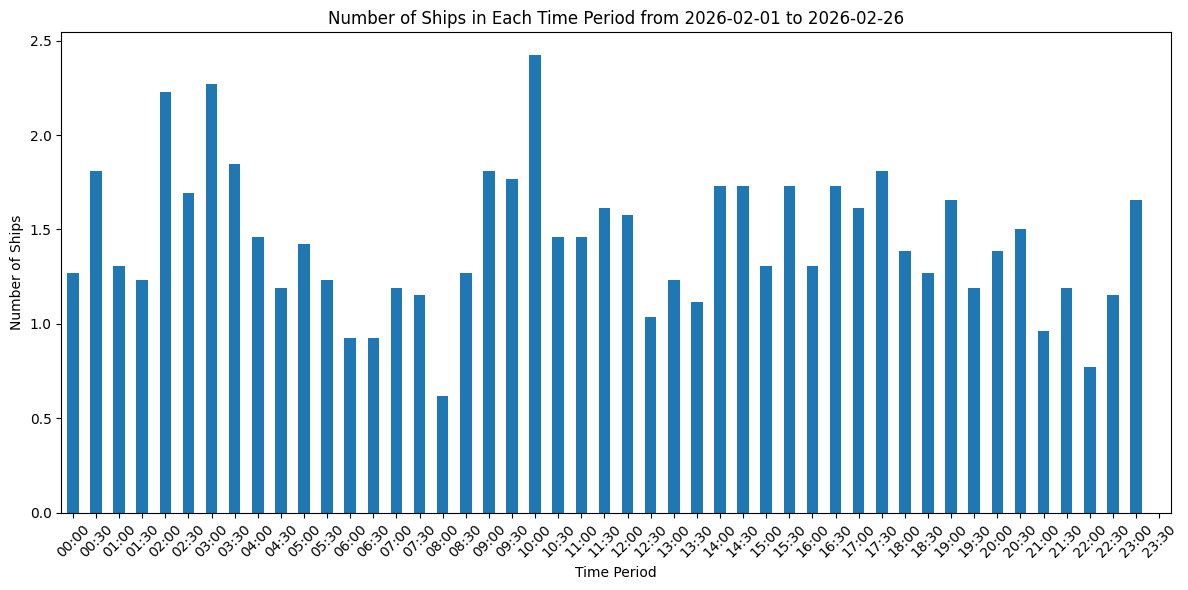

In [30]:
def plot_ship_distribution(gdf):
    '''Plot the distribution of ships based on the s_timestamp and l_timestamp. where x is the time in hours and y is the number of ships.'''
    
    gdf_temp = gdf.copy()
    for i in range(24):
        for j in range(2):
            if j == 0:
                time_str = f'{i:02d}:{j*30:02d}:00'
                time_end = f'{i:02d}:{(j+1)*30:02d}:00'
            else:
                time_str = f'{i:02d}:{j*30:02d}:00'
                time_end = f'{(i+1)%24:02d}:00:00'
            # print(time_str, time_end)
            period_start = pd.to_datetime(f'{time_str}', format='%H:%M:%S').time()
            period_end = pd.to_datetime(f'{time_end}', format='%H:%M:%S').time()
            gdf_temp[f'time_{time_str}'] = gdf_temp['s_timestamp'].dt.time.apply(lambda x: period_start <= x <= period_end) | gdf_temp['l_timestamp'].dt.time.apply(lambda x: period_start <= x <= period_end)
    # print(gdf_temp.columns)
    gdf_temp = pd.melt(gdf_temp, 
            id_vars=['id_track', 'sdate'], 
            value_vars=[col for col in gdf_temp.columns if col.startswith('time_')], 
            var_name='time_period', 
            value_name='present')

    # make time_period to be datetime.time type
    gdf_temp['time_period'] = gdf_temp['time_period'].apply(lambda x: pd.to_datetime(x.split('_')[1], format='%H:%M:%S').time().strftime('%H:%M'))
    gdf_cube = gdf_temp.groupby(['sdate', 'time_period'])[['present']].sum()
    
    # plot the number of ships in each time period
    plt.figure(figsize=(12, 6))
    gdf_cube.groupby('time_period')['present'].mean().plot(kind='bar')
    plt.xlabel('Time Period')
    plt.ylabel('Number of Ships')
    plt.title(f'Number of Ships in Each Time Period from {selected_start_time.date()} to {selected_end_time.date()}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_ship_distribution(gdf)

In [31]:
def count_avg_ships_perday(gdf):
    '''Count the average number of ships per day based on the s_timestamp'''
    gdf_temp = gdf.copy()
    avg_per_day = gdf_temp.groupby(gdf_temp['s_timestamp'].dt.date)['id_track'].nunique().mean()
    return avg_per_day

avg_ships_per_day = count_avg_ships_perday(gdf)
print(f'Average number of ships per day: {avg_ships_per_day:.1f}')

Average number of ships per day: 44.7


In [80]:
from shapely.geometry import Point


class ShipMetricsCalculator:
    def __init__(self, gdf, gdf_ais, bb_df, psd_df, comm_range_min=500, comm_range_max=15000):
        self.gdf = gdf
        self.gdf_ais = gdf_ais
        self.bb_df = bb_df.sort_index()
        self.psd_df = psd_df.sort_index()
        self.comm_range = [comm_range_min, comm_range_max]
        self.hydrophone_metadata = {'coordinates': [-123.1735774, 48.5583362], # Orcasound_lab coordinates
                                    'crs': {'properties': {'name': 'EPSG:4326'}, 
                                            'type': 'name'}, 'type': 'Point'}
    def get_ship_type(self, type_code):
        '''Map the ship type code to a more general category'''
        if np.isnan(type_code):
            return None
        elif type_code <= 0:
            return '-'
        elif type_code <=19:
            return 'reserved'
        elif type_code <= 29:
            return 'wing_in_ground'
        elif type_code <= 30:
            return 'fishing'
        elif type_code <= 32:
            return 'towing'
        elif type_code == 33:
            return 'dredging_or_underwater_operations'
        elif type_code == 34:
            return 'diving_operations'
        elif type_code == 35:
            return 'military_operations'
        elif type_code == 36:
            return 'sailing'
        elif type_code == 37:
            return 'pleasure_craft'
        elif type_code <= 39:        
            return 'reserved'
        elif type_code <= 49:
            return 'high_speed_craft'
        elif type_code == 50:
            return 'pilot_vessel'
        elif type_code == 51:
            return 'search_and_rescue_vessel'
        elif type_code == 52:
            return 'tug'
        elif type_code == 53:
            return 'port_tender'
        elif type_code == 54:
            return 'anti_pollution_equipment'
        elif type_code == 55:
            return 'law_enforcement'
        elif type_code <= 57:
            return 'spare_local_vessel'
        elif type_code == 58:
            return 'medical_transport'
        elif type_code == 59:
            return 'noncombatant_ship'
        elif type_code <= 69:
            return 'passenger'
        elif type_code <= 79:
            return 'cargo'
        elif type_code <= 89:
            return 'tanker'
        elif type_code <= 99:
            return 'other_type'
        else:
            return 'unknown'
            

    def get_ais_metadata(self, gdf, gdf_ais):
        '''Extract AIS metadata'''
        
        gdf_temp = pd.merge(gdf, gdf_ais, left_on='assoc_id', right_on='id_track', how='left')
        # ais_id = gdf.loc[gdf['id_track'] == ship_id, 'assoc_id'].values[0]
        gdf_temp = gdf_temp[['mmsi', 'imo', 'name', 'draft', 'type']]

        gdf_temp['mmsi'] = gdf_temp['mmsi'].astype('Int64').astype(str).replace('<NA>', value=None)
        gdf_temp['imo'] = gdf_temp['imo'].astype('Int64').astype(str).replace('<NA>', value=None) 
        gdf_temp['type_id'] = gdf_temp['type'].copy()
        gdf_temp['type'] = [self.get_ship_type(x) for x in gdf_temp['type_id'].values]
        
        return gdf_temp

    # def get_isolate_flag_old(self, gdf, s_timestamp, l_timestamp, id_track):
    #     '''Determine if a ship is an isolate ship, which means it is the only ship present during its presence time.'''
    #     mask = (
    #         (gdf['s_timestamp'].between(s_timestamp, l_timestamp) | (gdf['l_timestamp'].between(s_timestamp, l_timestamp)))
    #         & (gdf['id_track'] != id_track)
    #         )

    #     return sum(mask) == 0

    def get_isolate_flag(self, gdf, s_timestamp, l_timestamp, id_track):
        '''Determine if a ship is an isolate ship, which means it is the only ship present during its presence time.'''
        mask = (
            (gdf['s_timestamp'] < l_timestamp)
            & (gdf['l_timestamp'] > s_timestamp)
            & (gdf['id_track'] != id_track)
            )

        return sum(mask) == 0
    
    def prepare_sound_metrics(self):
        ''' Prepare the sound metrics by calculating the mean PSD in the communication frequency range and adding the broadband metric'''
        sound_df = self.psd_df.copy()
        sound_df['bb'] = self.bb_df['0']

        comm_min, comm_max = self.comm_range
        # select comm_min - comm_max Hz
        central_hz = [c for c in sound_df.columns
                    if c.isdigit() and comm_min <= int(c) <= comm_max]
        psd_selected = sound_df[central_hz]

        # bandwidth for 1/12 octave
        delta_f = np.array([int(hz) * (2**(1/24) - 2**(-1/24)) for hz in central_hz])
        
        # convert to linear
        psd_linear = 10**(psd_selected / 10)

        # integrate
        power = np.sum(psd_linear * delta_f, axis=1)

        # broadband level
        sound_df['comm_bb'] = 10 * np.log10(power)

        self._sound_df = sound_df[['index', 'comm_bb', 'bb']]


    def get_acoustic_metrics(self, s_time, l_time):
        '''Calculate the average PSD during the presence of each ship using vectorized operations'''
        times = self._sound_df['index'].between(s_time, l_time)
        sub = self._sound_df[times]
        
        comm_bb = sub['comm_bb']
        bb = sub['bb']

        return [
            comm_bb.mean(),
            comm_bb.quantile(0.95),
            comm_bb.quantile(0.75),
            comm_bb.quantile(0.5),
            bb.mean(),
            bb.quantile(0.95),
            bb.quantile(0.5),
            np.array(comm_bb.tolist()),
            np.array(bb.tolist())
        ]
  

    def get_distance_to_hydrophone(self, gdf, hydrophone_metadata, target_crs="EPSG:32610"):
        '''Calculate the distance from each ship to the hydrophone'''
        # Assuming the hydrophone location is given as a Point geometry
        pt_lon, pt_lat = hydrophone_metadata['coordinates'][0], hydrophone_metadata['coordinates'][1]
        point_gs = gpd.GeoSeries([Point(pt_lon, pt_lat)], crs="EPSG:4326") #lat/lon

        gdf_projected = gdf['geometry'].to_crs(target_crs)
        target_pt = point_gs.to_crs(target_crs).iloc[0]
        return gdf_projected.distance(target_pt)
        

    def get_all_ship_metrics(self):
        '''Calculate all ship metrics during the presence of each ship'''
        
        
        gdf_output = self.gdf[['id_track', 's_timestamp', 'l_timestamp', 'duration',
                               'avg_speed', 'max_speed', 'min_speed',
                               'distance', 'curviness', 'confidence', 'geometry']].reset_index(drop=True)
        
        gdf_output['min_dist'] = self.get_distance_to_hydrophone(gdf_output, hydrophone_metadata=self.hydrophone_metadata)
        gdf_output['is_isolated'] = gdf_output.apply(lambda x: 
                                        self.get_isolate_flag(self.gdf,
                                            s_timestamp=x['s_timestamp'], 
                                            l_timestamp=x['l_timestamp'],
                                            id_track=x['id_track']
                                            ), 
                                        axis=1
                                    )
        gdf_output[['mmsi', 'imo', 'name', 'draft', 'type_id', 'type']] = self.get_ais_metadata(self.gdf, self.gdf_ais)
        
        self.prepare_sound_metrics()
        acoustic_metrics = [
            self.get_acoustic_metrics(s, l)
            for s, l in zip(gdf_output['s_timestamp'], gdf_output['l_timestamp'])
        ]

        acoustic_metrics_cols = ['comm_avg', 'comm_95th', 'comm_75th', 'comm_50th',
                'bb_avg', 'bb_95th', 'bb_50th',
                'comm_bb_series', 'bb_series']

        gdf_output[acoustic_metrics_cols] = pd.DataFrame(acoustic_metrics, index=gdf_output.index)

        return gdf_output

    

In [81]:
MetricsCalculator = ShipMetricsCalculator(gdf, gdf_ais, bb_df, psd_df)
ship_metrics = MetricsCalculator.get_all_ship_metrics()
ship_metrics

,id_track,s_timestamp,l_timestamp,duration,avg_speed,max_speed,min_speed,distance,curviness,confidence,...,type,comm_avg,comm_95th,comm_75th,comm_50th,bb_avg,bb_95th,bb_50th,comm_bb_series,bb_series
0,48951697,2026-02-01 02:01:59,2026-02-01 02:19:15,1036.0,10.152697,11.10,2.00,5.637372,1.035614,0.995605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[]
1,48951936,2026-02-01 02:19:31,2026-02-01 02:42:46,1395.0,11.615362,13.30,7.70,8.523223,1.029750,0.997607,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[]
2,48952300,2026-02-01 03:00:16,2026-02-01 03:20:07,1191.0,0.062500,1.40,0.00,0.697199,4.369674,0.991064,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[]
3,48952954,2026-02-01 04:06:07,2026-02-01 04:47:50,2503.0,19.361417,34.20,4.59,24.547278,1.083383,0.873836,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[]
4,48953531,2026-02-01 05:10:45,2026-02-01 05:33:15,1350.0,17.616510,20.80,13.40,12.553011,1.012763,0.964262,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1157,49371098,2026-02-25 21:04:28,2026-02-25 21:08:29,241.0,12.376053,13.30,7.20,1.618160,1.016590,0.997372,...,NaN,68.631835,69.243874,68.742518,68.576045,8.988839,11.836686,8.774899,"[68.73268226265138, 68.94786362821213, 69.0713...","[9.506874088165333, 10.609169727091356, 11.733..."
1158,49372032,2026-02-25 22:37:12,2026-02-25 23:17:43,2431.0,10.259162,11.80,3.50,13.821371,1.053098,0.997283,...,NaN,68.859219,69.312904,69.018067,68.847547,10.376177,12.686422,10.446199,"[68.58803573912368, 68.40767936095705, 68.6583...","[8.337347558540017, 7.413873833996462, 8.55252..."
1159,49373049,2026-02-26 00:39:31,2026-02-26 00:43:26,235.0,9.508857,9.69,7.00,1.236744,1.012627,0.998540,...,NaN,68.593171,68.825650,68.669802,68.593318,7.765834,9.071956,7.724371,"[68.27647586299676, 68.33261157647772, 68.3808...","[6.171120938466174, 6.524349654538042, 6.83687..."
1160,49373093,2026-02-26 00:44:31,2026-02-26 01:15:50,1879.0,12.342759,14.20,11.50,12.440104,1.053983,0.994094,...,NaN,68.461430,68.896260,68.672574,68.482656,8.226524,11.382651,8.077733,"[68.38314678410589, 68.66470443694132, 68.7986...","[6.92272542279845, 8.41950443492054, 8.9997921..."


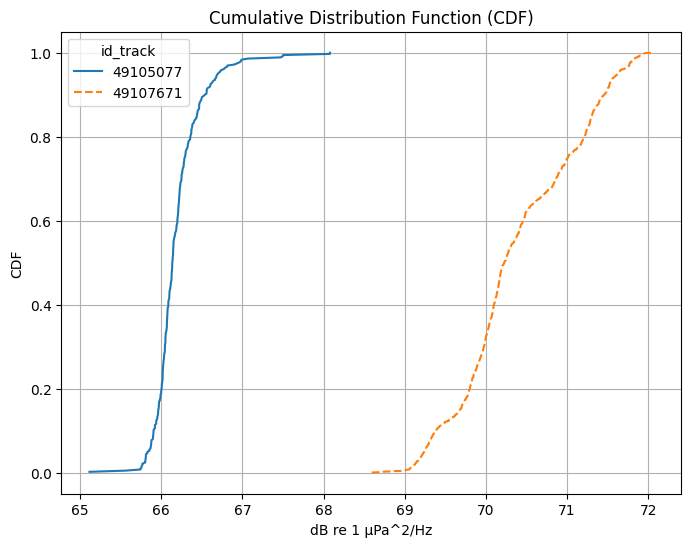

In [82]:
ind1, ind2 = 351, 353

def plot_cdf(ind1, ind2=None):
    '''Plot the CDF of a given series'''
    series1 = ship_metrics.iloc[ind1]['comm_bb_series']
    

    sorted_series = np.sort(series1)

    cdf = np.arange(1, len(sorted_series)+1) / len(sorted_series)
    
    plt.figure(figsize=(8, 6))
    plt.plot(sorted_series, cdf, linestyle='-')
    if ind2 is not None:
        series2 = ship_metrics.iloc[ind2]['comm_bb_series']
        sorted_series2 = np.sort(series2)
        cdf2 = np.arange(1, len(sorted_series2)+1) / len(sorted_series2)
        plt.plot(sorted_series2, cdf2, linestyle='--')
        plt.legend(ship_metrics.iloc[[ind1, ind2]]['id_track'].values.astype(str), title='id_track')
    plt.xlabel('dB re 1 μPa^2/Hz')
    plt.ylabel('CDF')
    plt.title('Cumulative Distribution Function (CDF)')
    plt.grid()
    plt.show()


plot_cdf(ind1, ind2)

In [22]:
psd_df_temp = psd_df.copy()

for id_track in gdf['id_track'].unique():
    s_time = gdf.loc[gdf['id_track'] == id_track, 's_timestamp'].values[0]
    l_time = gdf.loc[gdf['id_track'] == id_track, 'l_timestamp'].values[0]
    psd_df_temp['track_' + str(id_track)] = psd_df_temp['index'].between(s_time, l_time)

psd_df_temp['ship_presence'] = psd_df_temp[[col for col in psd_df_temp.columns if col.startswith('track_')]].any(axis=1)
psd_df_temp

/var/folders/1s/89d5t8ln1xd3m_vytz6l1v2w0000gn/T/ipykernel_67509/1799193361.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  psd_df_temp['track_' + str(id_track)] = psd_df_temp['index'].between(s_time, l_time)
/var/folders/1s/89d5t8ln1xd3m_vytz6l1v2w0000gn/T/ipykernel_67509/1799193361.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  psd_df_temp['track_' + str(id_track)] = psd_df_temp['index'].between(s_time, l_time)
/var/folders/1s/89d5t8ln1xd3m_vytz6l1v2w0000gn/T/ipykernel_67509/1799193361.py:6: PerformanceWarning: DataFr

,index,67,71,75,80,85,90,95,100,106,...,track_49183042,track_49183177,track_49183236,track_49183268,track_49184777,track_49185366,track_49185432,track_49185458,track_49185466,ship_presence
0,2026-02-07 12:18:13,17.000665,19.294618,20.197513,19.322835,18.659616,21.115209,20.999857,22.689917,19.256854,...,False,False,False,False,False,False,False,False,False,True
1,2026-02-07 12:18:14,19.467176,19.457936,21.374846,21.176110,22.079493,22.903928,21.202620,23.469553,20.831801,...,False,False,False,False,False,False,False,False,False,True
2,2026-02-07 12:18:15,19.811217,19.420876,21.221506,21.924292,21.787503,23.446219,22.431197,22.463962,21.759176,...,False,False,False,False,False,False,False,False,False,True
3,2026-02-07 12:18:16,18.480414,18.302718,20.319762,23.340436,22.431197,22.981302,22.731241,22.208427,20.720595,...,False,False,False,False,False,False,False,False,False,True
4,2026-02-07 12:18:17,18.840161,18.418112,19.089674,21.330246,21.882432,22.463962,22.962795,22.295555,21.965951,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583190,2026-02-13 23:59:51,23.402299,23.437453,24.555164,23.048825,21.605313,21.673635,22.857171,22.972053,21.088430,...,False,False,False,False,False,False,False,False,False,False
583191,2026-02-13 23:59:52,24.687814,22.781832,24.454329,24.482889,23.130983,22.134015,21.540087,22.358677,20.583616,...,False,False,False,False,False,False,False,False,False,False
583192,2026-02-13 23:59:53,24.280974,24.344413,23.758871,23.112793,23.495728,22.866543,22.872785,21.141906,20.922096,...,False,False,False,False,False,False,False,False,False,False
583193,2026-02-13 23:59:54,23.820632,24.063378,23.736302,24.014275,22.522628,22.437760,22.574446,21.882432,21.576384,...,False,False,False,False,False,False,False,False,False,False
